# Chapter 156 — Identity Matrix

> **Prerequisites:** Matrix multiplication *(ch154)*, matrix transpose *(ch155)*
> **You will learn:**
> - The identity matrix as the "do nothing" transformation
> - Properties: AI = IA = A; I² = I
> - Kronecker delta notation
> - Generalized identity (rectangular case)
> - How identity appears in regularization and debugging
>
> **Environment:** Python 3.x, numpy

Identity 2x2:
[[1. 0.]
 [0. 1.]]

Identity 3x3:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Identity 4x4:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

AI = A: True
IA = A: True

I3 @ A_rect = A_rect: True
A_rect @ I5 = A_rect: True


C:\Users\user\AppData\Local\Temp\ipykernel_22748\1367529355.py:28: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  circle = np.row_stack([np.cos(t), np.sin(t)])
C:\Users\user\AppData\Local\Temp\ipykernel_22748\1367529355.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


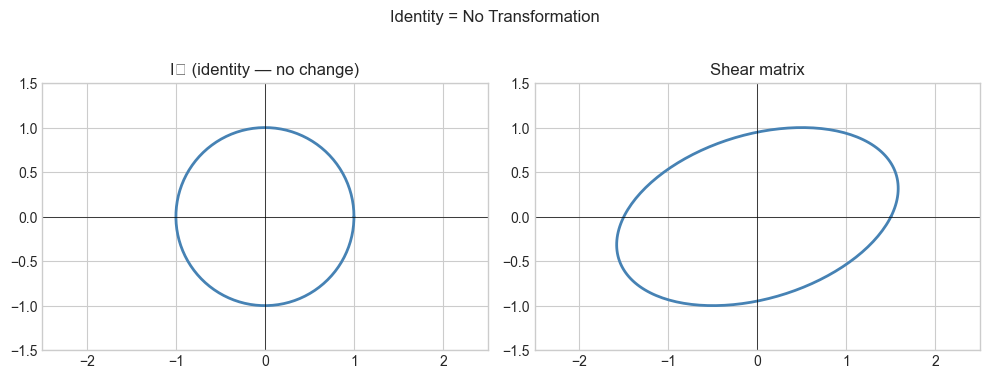


Regularized matrix (A + 0.1*I):
Diagonal of A: [ 0.441  1.582 -1.193 -0.7  ]
Diagonal of A + λI: [ 0.541  1.682 -1.093 -0.6  ] (each increased by λ)


In [1]:
# --- Identity Matrix: Properties and Applications ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# The n×n identity matrix: I[i,j] = 1 if i==j, else 0
# Kronecker delta: δᵢⱼ
for n in [2, 3, 4]:
    I = np.eye(n)
    print(f"Identity {n}x{n}:\n{I}\n")

# Key property: AI = IA = A (for square A)
np.random.seed(5)
A = np.random.randn(4, 4)
I4 = np.eye(4)
print(f"AI = A: {np.allclose(A @ I4, A)}")
print(f"IA = A: {np.allclose(I4 @ A, A)}")

# Rectangular: left identity vs right identity
A_rect = np.random.randn(3, 5)
I3 = np.eye(3); I5 = np.eye(5)
print(f"\nI3 @ A_rect = A_rect: {np.allclose(I3 @ A_rect, A_rect)}")
print(f"A_rect @ I5 = A_rect: {np.allclose(A_rect @ I5, A_rect)}")

# --- Visualization: I as transformation ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t = np.linspace(0, 2*np.pi, 200)
circle = np.row_stack([np.cos(t), np.sin(t)])
A_shear = np.array([[1.5, 0.5],[0,1]])

for ax, (M, title) in zip(axes, [(np.eye(2), 'I₂ (identity — no change)'), (A_shear, 'Shear matrix')]):
    result = M @ circle
    ax.plot(result[0], result[1], 'steelblue', lw=2)
    ax.set_xlim(-2.5,2.5); ax.set_ylim(-1.5,1.5)
    ax.set_aspect('equal'); ax.set_title(title)
    ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)

plt.suptitle('Identity = No Transformation', fontsize=12)
plt.tight_layout(); plt.show()

# Regularization: A + λI
lam = 0.1
A_reg = A + lam * I4
print(f"\nRegularized matrix (A + 0.1*I):")
print(f"Diagonal of A: {np.diag(A).round(3)}")
print(f"Diagonal of A + λI: {np.diag(A_reg).round(3)} (each increased by λ)")

---

## 4. Mathematical Formulation

```
I_n[i,j] = δᵢⱼ  (Kronecker delta)
          = 1 if i == j
          = 0 if i ≠ j

Properties:
  AI = IA = A        for any compatible A
  Iᵀ = I             symmetric
  I⁻¹ = I            self-inverse
  det(I) = 1

Regularization: A + λI
  Adds λ to each diagonal entry
  Ensures positive definiteness if λ > max(-eigenvalues(A))
  Used in: Ridge regression, Tikhonov regularization, Newton's method
```

---

## 7. Exercises

**Easy 1.** What is the result of `I_4 @ v` for any vector v of length 4?

**Easy 2.** Write a function `is_identity(A)` that checks if a matrix is the identity.

**Medium 1.** Show that for any invertible matrix A, `A @ A⁻¹ = I`. Test numerically.

**Medium 2.** What is the eigendecomposition of the identity matrix? (Hint: every vector is an eigenvector — what is the eigenvalue?) *(Connections: ch169)*

**Hard.** Prove that if AB = I and BA = I, then B = A⁻¹. Write the proof as a sequence of equations.

---

## 9. Chapter Summary & Connections

- The n×n identity matrix `I` satisfies `AI = IA = A` for any compatible A.
- `I[i,j] = δᵢⱼ` (Kronecker delta) — ones on diagonal, zeros elsewhere.
- `A + λI` (Tikhonov regularization) stabilizes ill-conditioned systems *(reappears in ch162 — Matrix Factorization and ch181 — Linear Regression)*.

**Backward connection:** Identity is the linear algebra equivalent of the number 1 — it is the multiplicative identity in the ring of square matrices.

**Forward connections:**
- In ch157 (Matrix Inverse), we define A⁻¹ as the matrix satisfying `AA⁻¹ = I`.
- In ch171 (Eigenvalue Computation), I appears in the characteristic equation `det(A - λI) = 0`.